# **I. Data**
## **I.A. Tweets**

We first load, examine and clean our data Tweet data. We merge ```Tweet.csv``` with ```Company_Tweet.csv``` in order to obtain ticker data per tweet, without duplicata. We optimize this process using vectorization.

In [3]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=SyntaxWarning)

df_tweets = pd.read_csv("data/Tweet/Tweet.csv")
df_ticker = pd.read_csv("data/Tweet/Company_Tweet.csv")

df_ticker['ticker'] = df_ticker['ticker_symbol'].astype(str) + ', '
df_ticker_agg = df_ticker.groupby('tweet_id', as_index=False).sum()
df_ticker_agg['ticker'] = df_ticker_agg['ticker'].str.rstrip(', ')

df = pd.merge(df_tweets, df_ticker_agg, on='tweet_id', how='left')
dates = pd.to_datetime(df['post_date'], unit='s')

print(f"Total tweets: {len(df)}")

Total tweets: 3717964


Our dataset contains 3,717,964 tweets: it is necessary to clean this mass of data entries.

Many of these tweets are irrelevant to current financial market conditions and use the $Cashtags system solely for advertising purposing. Examples include: 
- Give your brain a workout with Squares – Challenging Puzzle Game http://dlvr.it/7zTvGm #AppAdvice $AAPL
- Swing Trading: Up To 8.91% Return In 14 Days http://ow.ly/GDkrZ #swingtrading #forecast #techstock $MWW $AAPL $TSLA
- S&P100 #Stocks Performance $HD $LOW $SBUX $TGT $DVN $IBM $AMZN $F $APA $GM $MS $HAL $DIS $MCD $BMY $XOM  more@ http://12Stocks.com/sp100
- $UNP $ORCL $QCOM $MSFT $AAPL Top scoring mega caps right now at the end of 2014 on http://GetAOM.com
- http://BiloSelhi.com subscribers alerted to 10-250% gain options. JOIN NOW $QQQ $AAPL 
- Free course - Capital usage with Options http://bit.ly/CapiEffi $GLD $SLV $TSLA
- Algo Trading: Up to 61.09% Return In 1 Year http://ow.ly/GVxVm #tech #stocks $AAPL $TSLA
- #toptickertweets $AAPL $SPDC $SPY $TSLA $CLDN $YELP $TWTR $FB $FXE $EWG #sentiquant 20150427 18:00:04:186
- THE BINARY OPTIONS COMPETITION WIN $100,000 http://rbn.cm/VbMIHH $LNKD $AAPL $GOOGL $GOOLD #bones #options #forex #forextrading #Bonus

We should remove these tweets from our dataset: they don't carry relevant information for markets and are purely noise.

Hence, we filter out: 
- Advertisements detected with suspicious keywords
- Tweets including over 3+ stock tickers: they seek visibility instead of providing relevant information reflecting market sentiment

To facilitate finBERT sentiment analysis and limit tweet length, we also delete from all URLs textual content (they can sometimes be lenghty and go over our token limit). After this, our heaviest tweet went from 809 to 202 tokens.

In [4]:
keywords = ["JOIN NOW", "subscriber", "#AppAdvice", "Free course",
            "Free courses", "Competition", "free trial", "sign up",
            "join our", "free trial", "sign up", "join our", "In 14 days",
            "Algo Trading", "Algorithmic Trading", "Premium Package",
            "Stock Picking by Algorithms", "Top 10 Stock Picks", "AI-Based Algorithms"
            "#Stocks Trend", "#Stocks Performance", "12Stocks.com", "ow.ly",
            "SUBSCRIBE", "subscribers", "#howtotrade"]

spam_pattern = "|".join(keywords)
df_spam = df[~df['body'].str.contains(spam_pattern, case=True, na=False)]
print(f"{len(df)-len(df_spam)} tweets removed after spam-keywords cleaning")

cashtag_regex = r'\$[a-zA-Z]{2,4}(?=\s|,|$)'
ticker_count = df['body'].str.findall(cashtag_regex).str.len()
df_cashtag = df[ticker_count <= 4].copy()
print(f"{len(df)-len(df_cashtag)} tweets removed after cashtag filtering")

df = pd.merge(df_spam, df_cashtag, how='inner')
df = df.reset_index(drop=True)
dates = pd.to_datetime(df['post_date'], unit='s')


88296 tweets removed after spam-keywords cleaning
454421 tweets removed after cashtag filtering


We then compute basic descriptive metrics of the global datasets, as well as metrics regarding individual stocks.

In [5]:
import pandas as pd
df = pd.read_csv("data/output/Tweets_cleaned.csv")

# Metrics
print(f"Total tweets: {len(df)}")
print(f"Earliest tweet: {dates.min()}")
print(f"Latest tweet: {dates.max()}")

companies = {"AAPL": "AAPL", "GOOGL": "GOOG", "AMZN": "AMZN", "TSLA": "TSLA", "MSFT": "MSFT"}
stats_d = []
stats_w = []

for name, ticker in companies.items():
    sub_df = df[df['ticker'].str.contains(ticker, na=False)]

    counts_daily = sub_df.groupby(dates.dt.date).size()
    counts_weekly = sub_df.groupby(dates.dt.to_period('W')).size()

    stats_d.append({"Company": name, "Mean": counts_daily.mean(), "Median": counts_daily.median(), "Std": counts_daily.std(), "Min": counts_daily.min(), "Max": counts_daily.max()})
    stats_w.append({"Company": name, "Mean": counts_weekly.mean(), "Median": counts_weekly.median(), "Std": counts_weekly.std(), "Min": counts_weekly.min(), "Max": counts_weekly.max()})

total_daily = df.groupby(dates.dt.date).size()
total_weekly = df.groupby(dates.dt.to_period('W')).size()

stats_d.append({"Company": "Total", "Mean": total_daily.mean(), "Median": total_daily.median(),"Std": total_daily.std(), "Min": total_daily.min(), "Max": total_daily.max()})
stats_w.append({"Company": "Total", "Mean": total_weekly.mean(), "Median": total_weekly.median(),"Std": total_weekly.std(), "Min": total_weekly.min(), "Max": total_weekly.max()})

print(f"\nDaily {pd.DataFrame(stats_d).set_index('Company').rename_axis(None).round(2)}")
print(f"\nWeekly {pd.DataFrame(stats_w).set_index('Company').rename_axis(None).round(2)}")

Total tweets: 2906577
Earliest tweet: 2015-01-01 00:01:36
Latest tweet: 2019-12-31 23:55:53

Daily           Mean  Median      Std  Min   Max
AAPL    608.54   459.0   517.97    2  5110
GOOGL   264.83   187.0   242.26    4  1649
AMZN    291.29   225.0   232.83    4  2017
TSLA    554.38   368.0   537.57    3  3477
MSFT    156.36   109.0   151.42    1  1352
Total  1798.62  1701.5  1003.68  173  7350

Weekly            Mean   Median      Std   Min    Max
AAPL    4233.56   3772.0  2503.28   528  13054
GOOGL   1844.65   1537.5  1144.87   152   5666
AMZN    2021.45   1867.5   975.51   344   5816
TSLA    3859.15   2766.5  2940.94   373  12191
MSFT    1089.11    851.0   745.61   151   4728
Total  12528.35  12095.0  3865.40  2551  24640


Our tweet datasets extends over 5 years (2015-2019), covering 2,906,577 tweets. There are 1545 tweets per day on average, ranging from 156 to 7274 per day. This minimum indicates no missing days in our dataset. On a weekly basis, there are on average 11356 tweets.

The dataset covers 5 companies: Apple ($AAPL), Google ($GOOG and $GOOGL), Amazon ($AMZN), Tesla Inc. ($TSLA) and Microsoft ($MSFT). Apple is by far the most mentioned company, altough, Tesla surpasses it in both daily and weekly maximum mentions. 

Plotting these tweets frequencies allow us to grasp the distribution of tweets over time, both on a company basis and global basis.

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({        
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman"],
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.4,
    "grid.linestyle": "-",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

grays = ["0.0", "0.35", "0.6", "0.75"] 

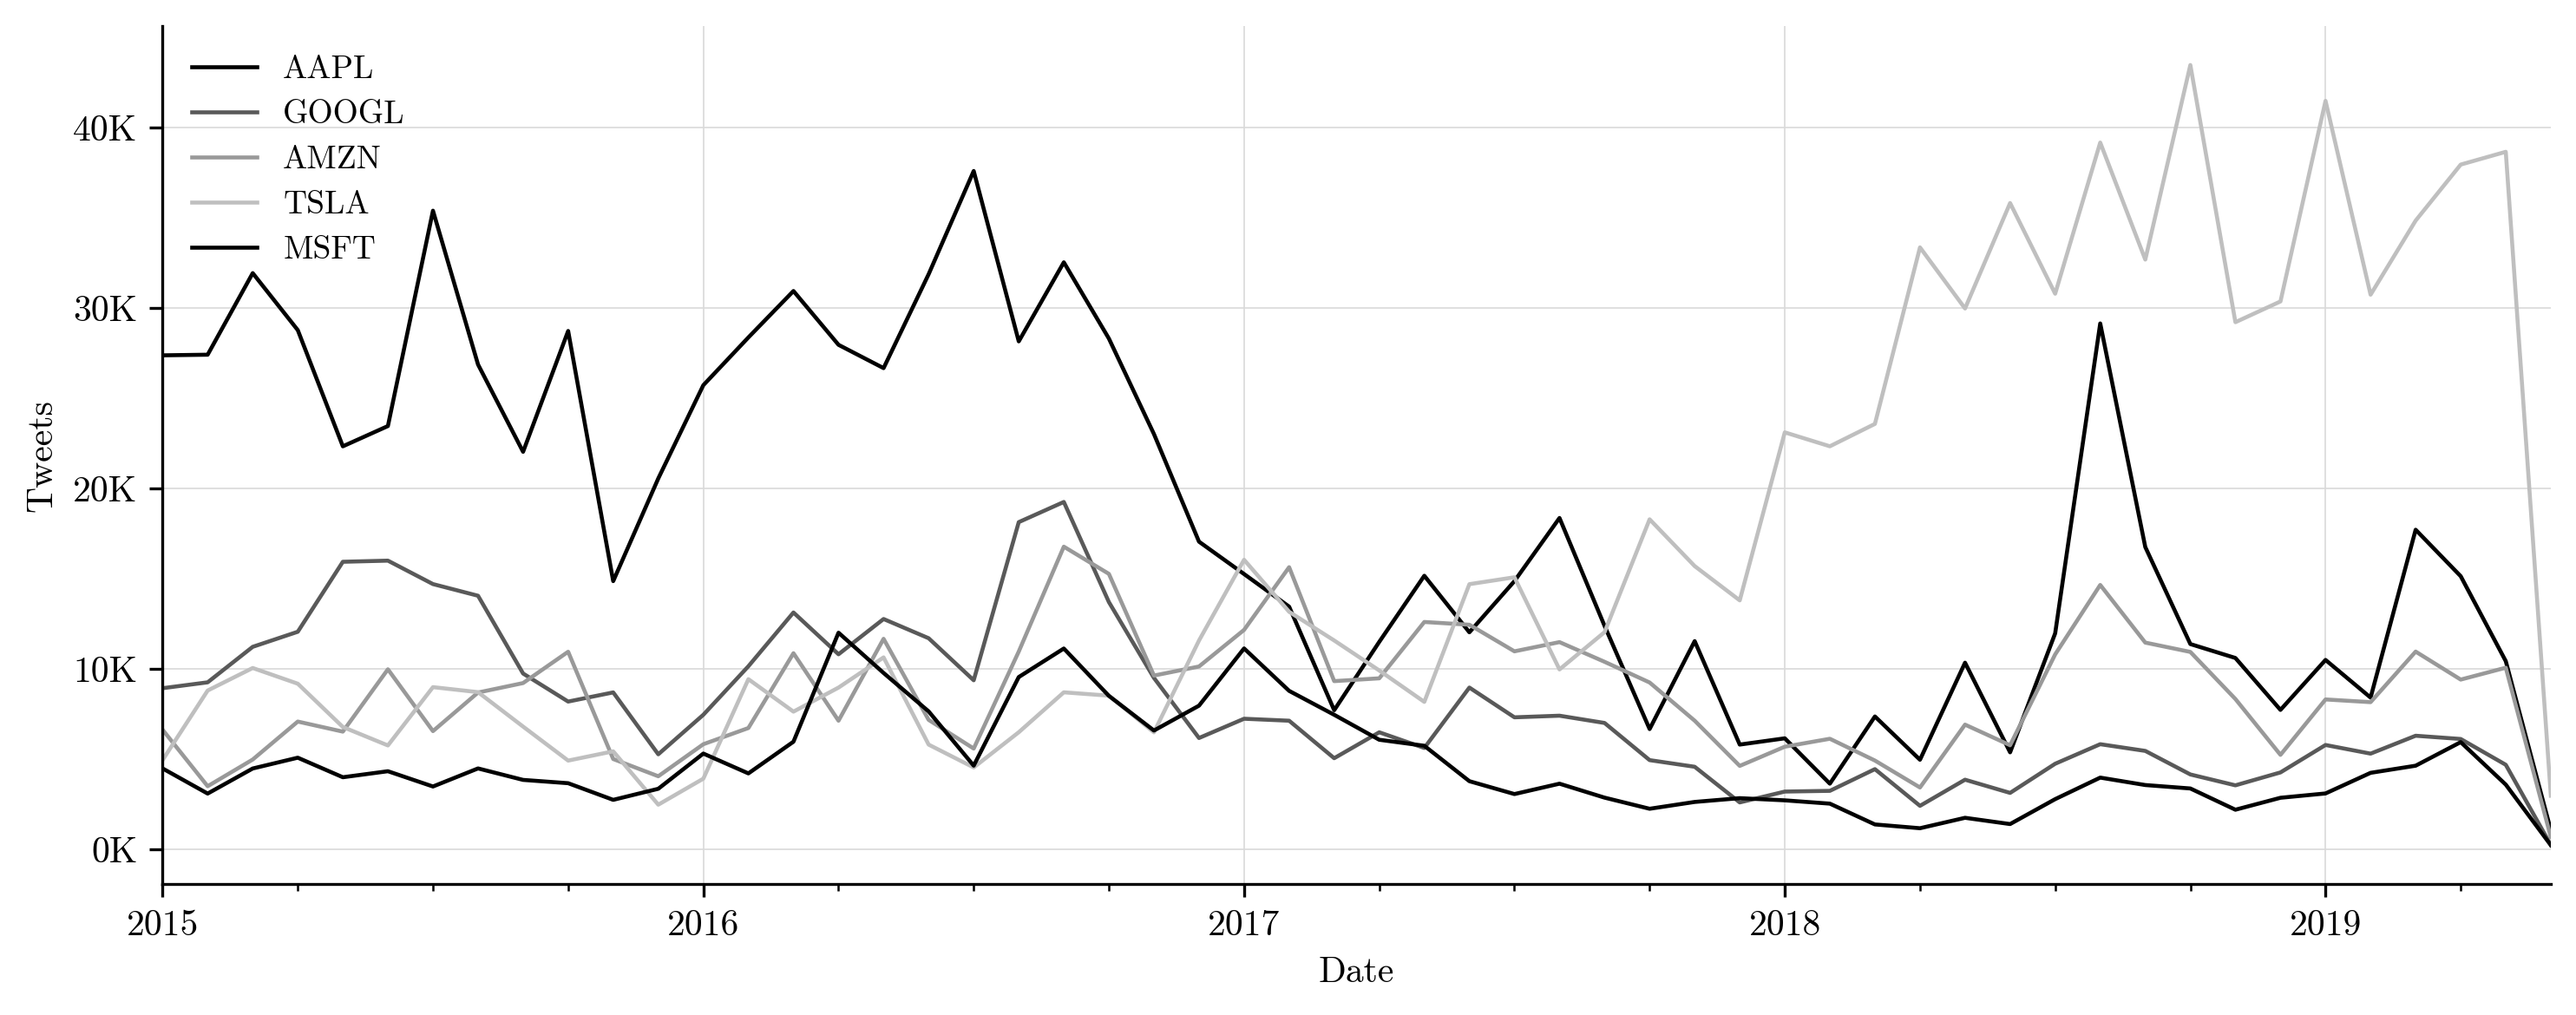

In [7]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

for i, (name, ticker) in enumerate(companies.items()):
    sub_df = df[df['ticker'].str.contains(ticker, na=False)]
    counts_monthly = sub_df.groupby(dates.dt.to_period('M')).size()
    counts_monthly.plot(
        ax=ax,
        label=name,
        color=grays[i % len(grays)],
        linewidth=1.1
    )

ax.set_xlabel("Date")
ax.set_ylabel("Tweets")
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.savefig("media/tweets_per_period.png", bbox_inches="tight")
plt.show()

We then plot daily/weekly/quarterly sentiment evolution across all periods and firms.

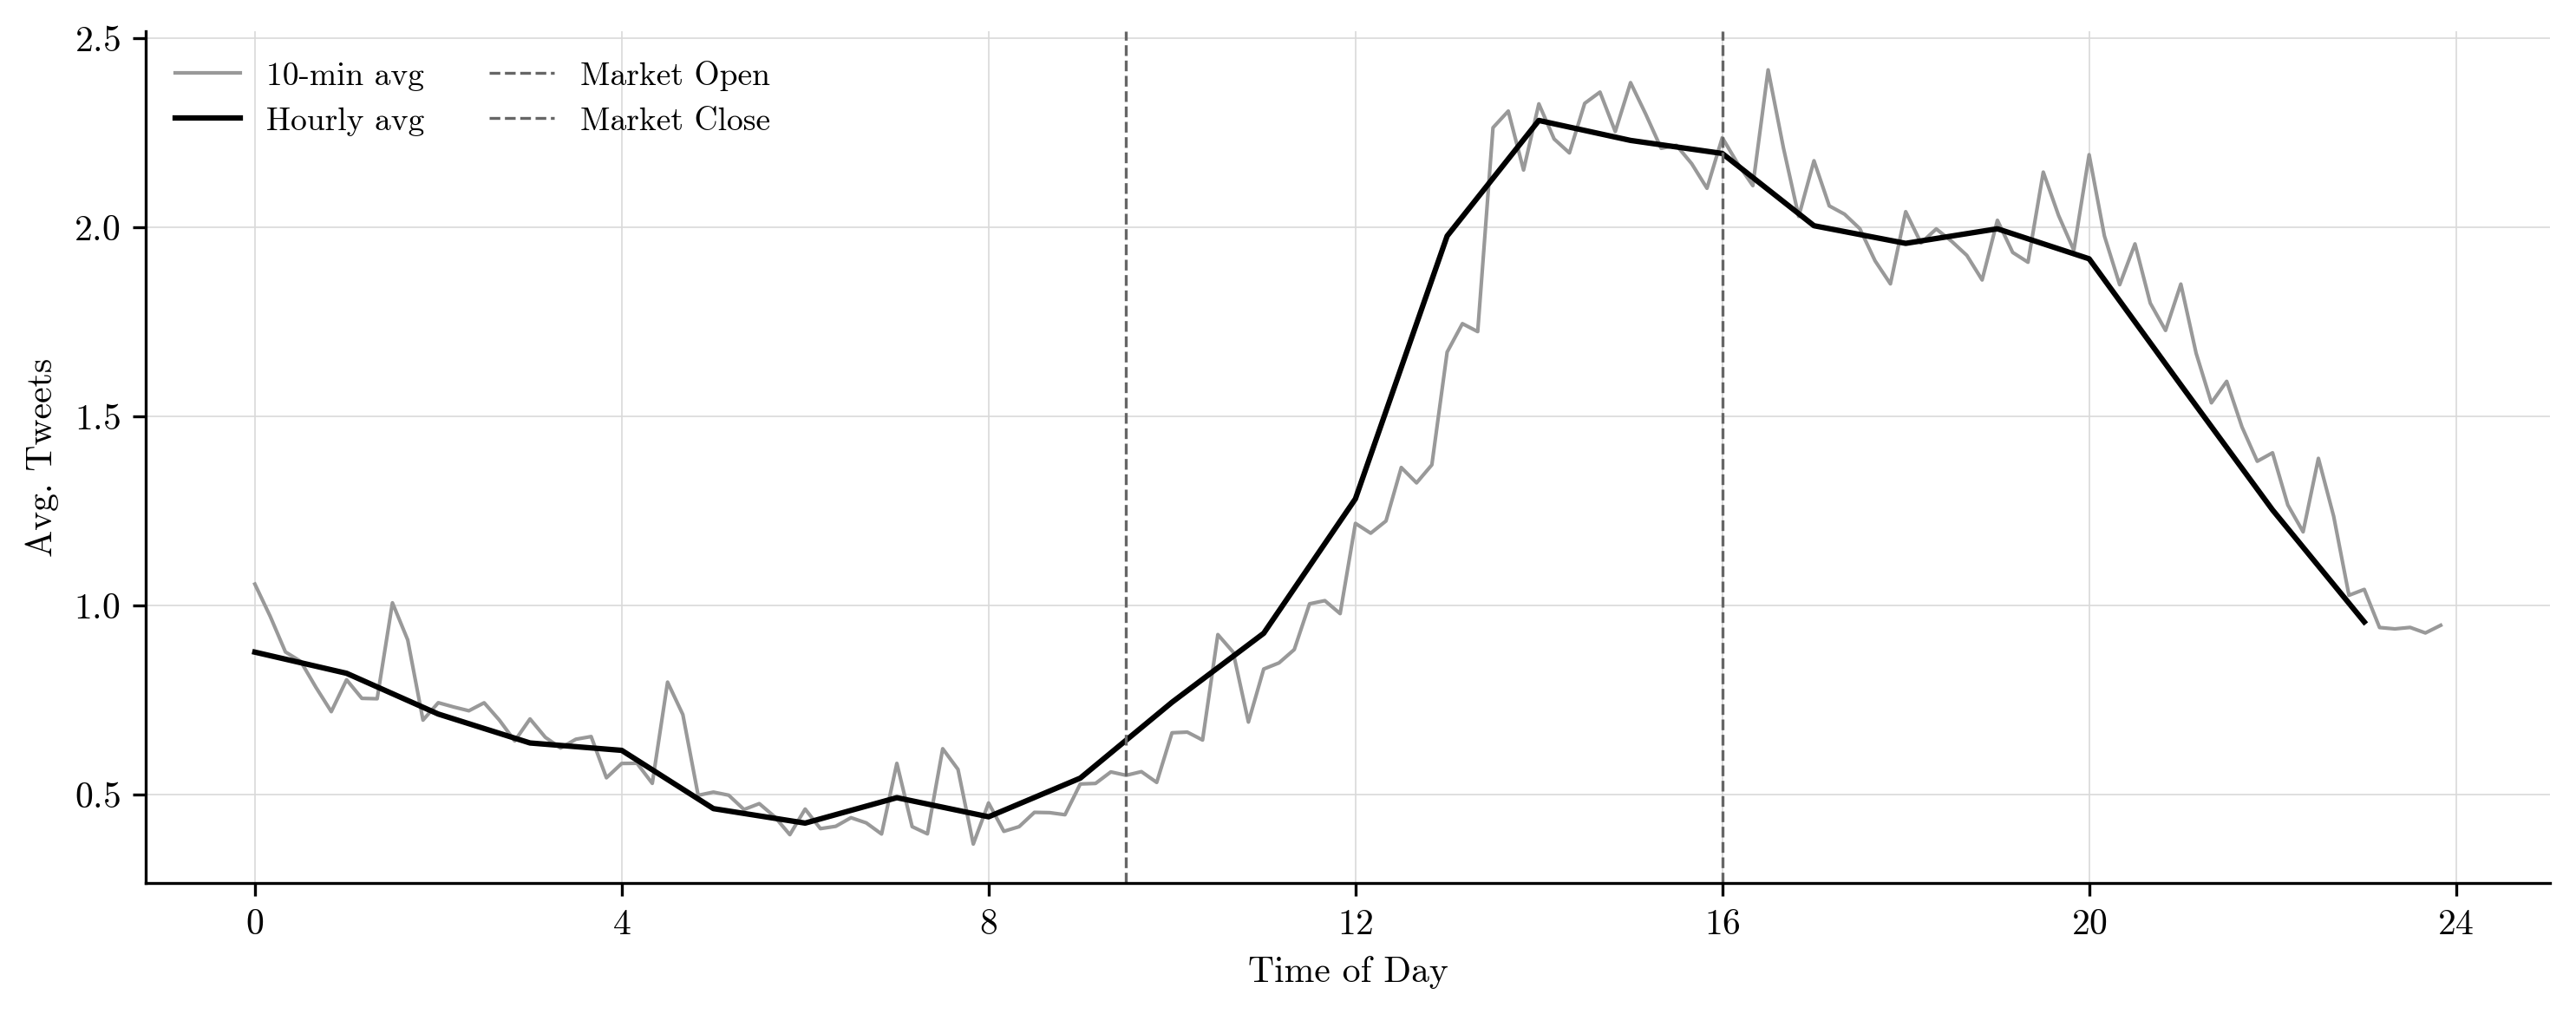

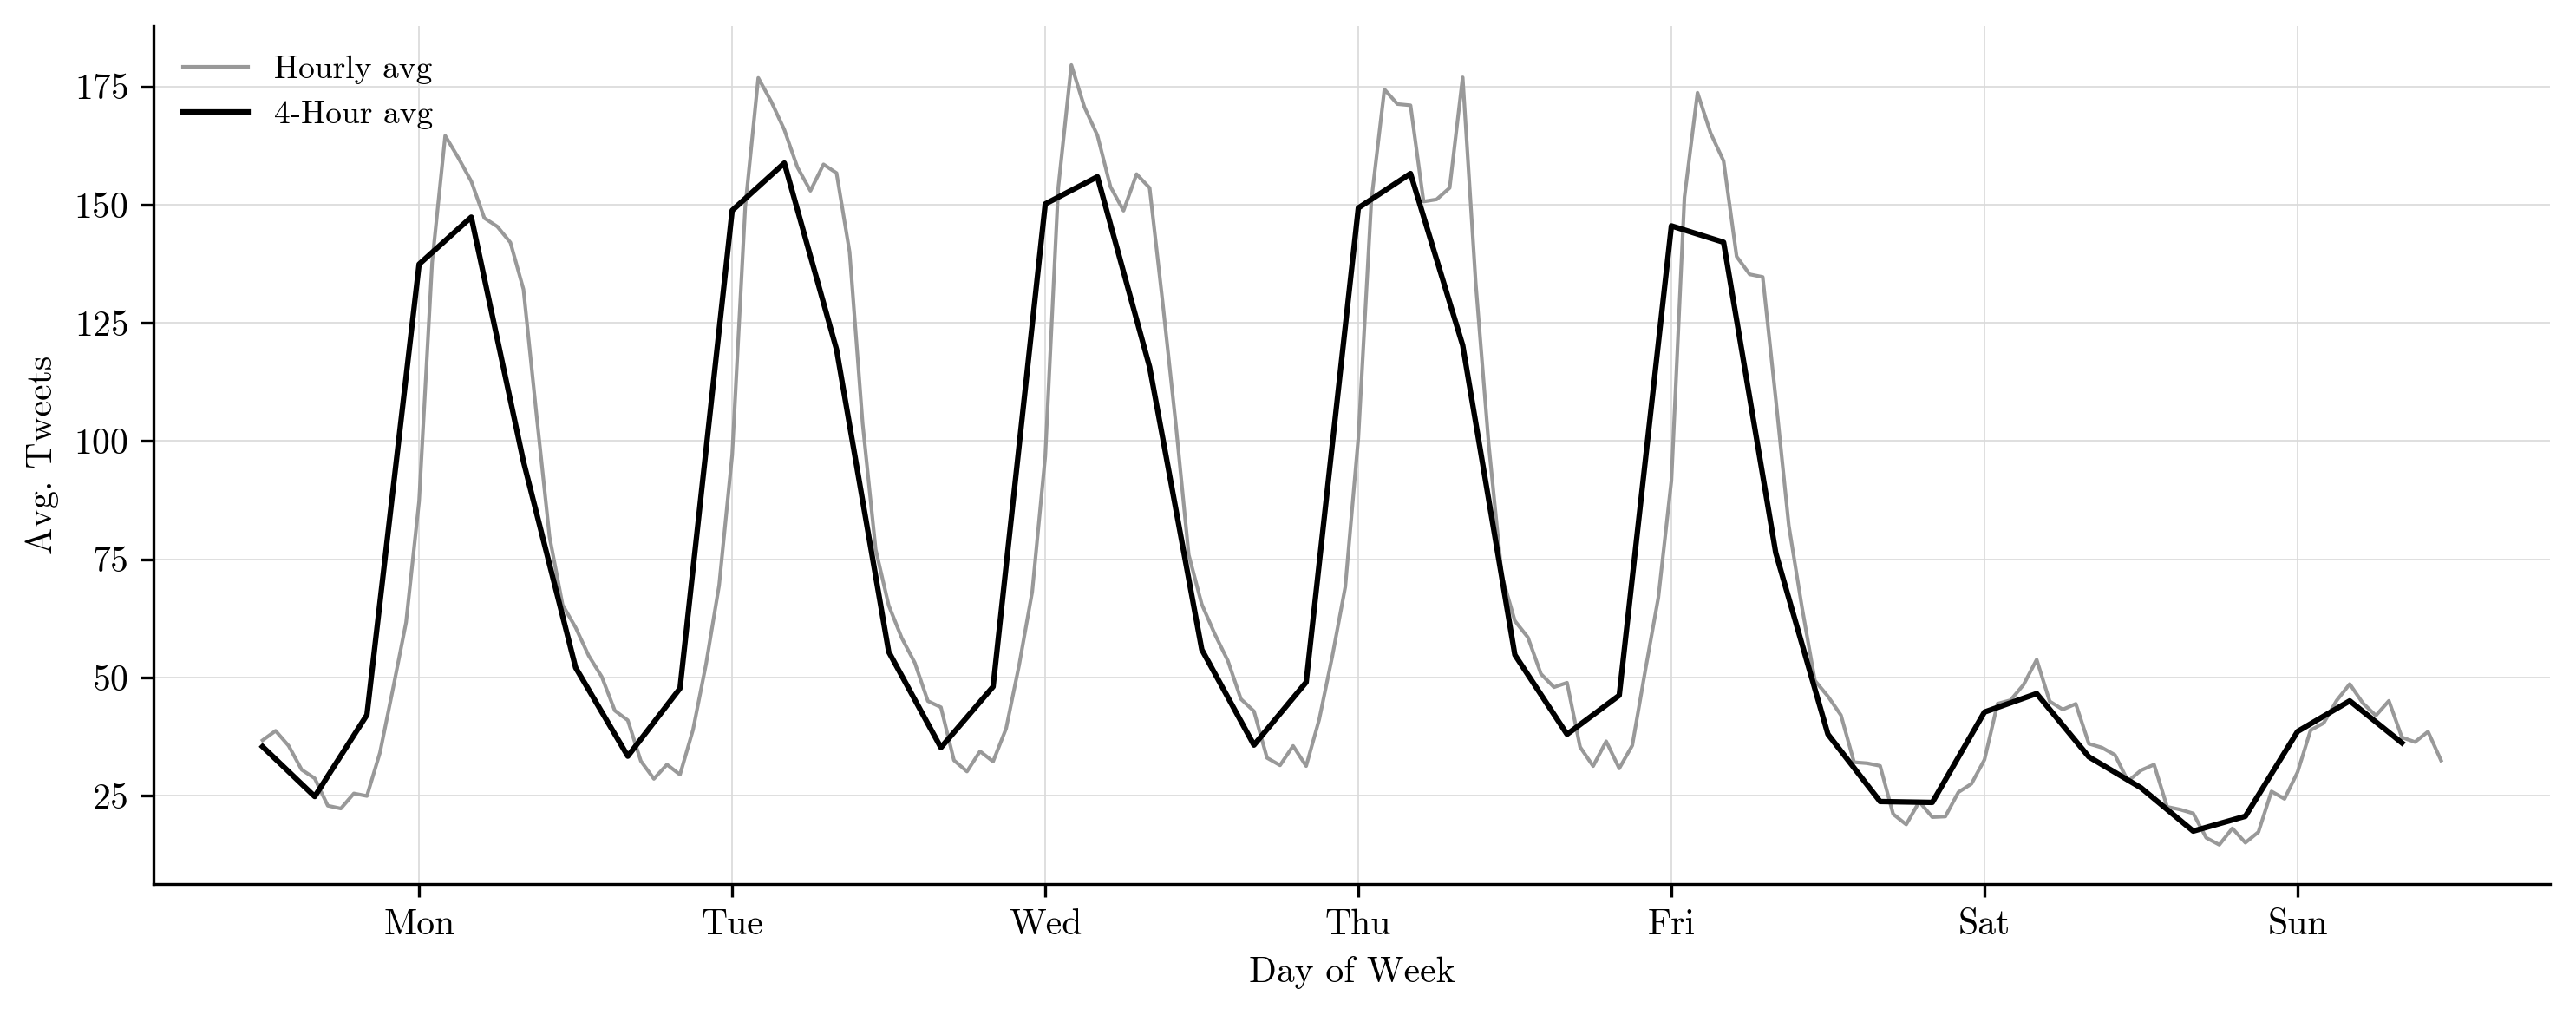

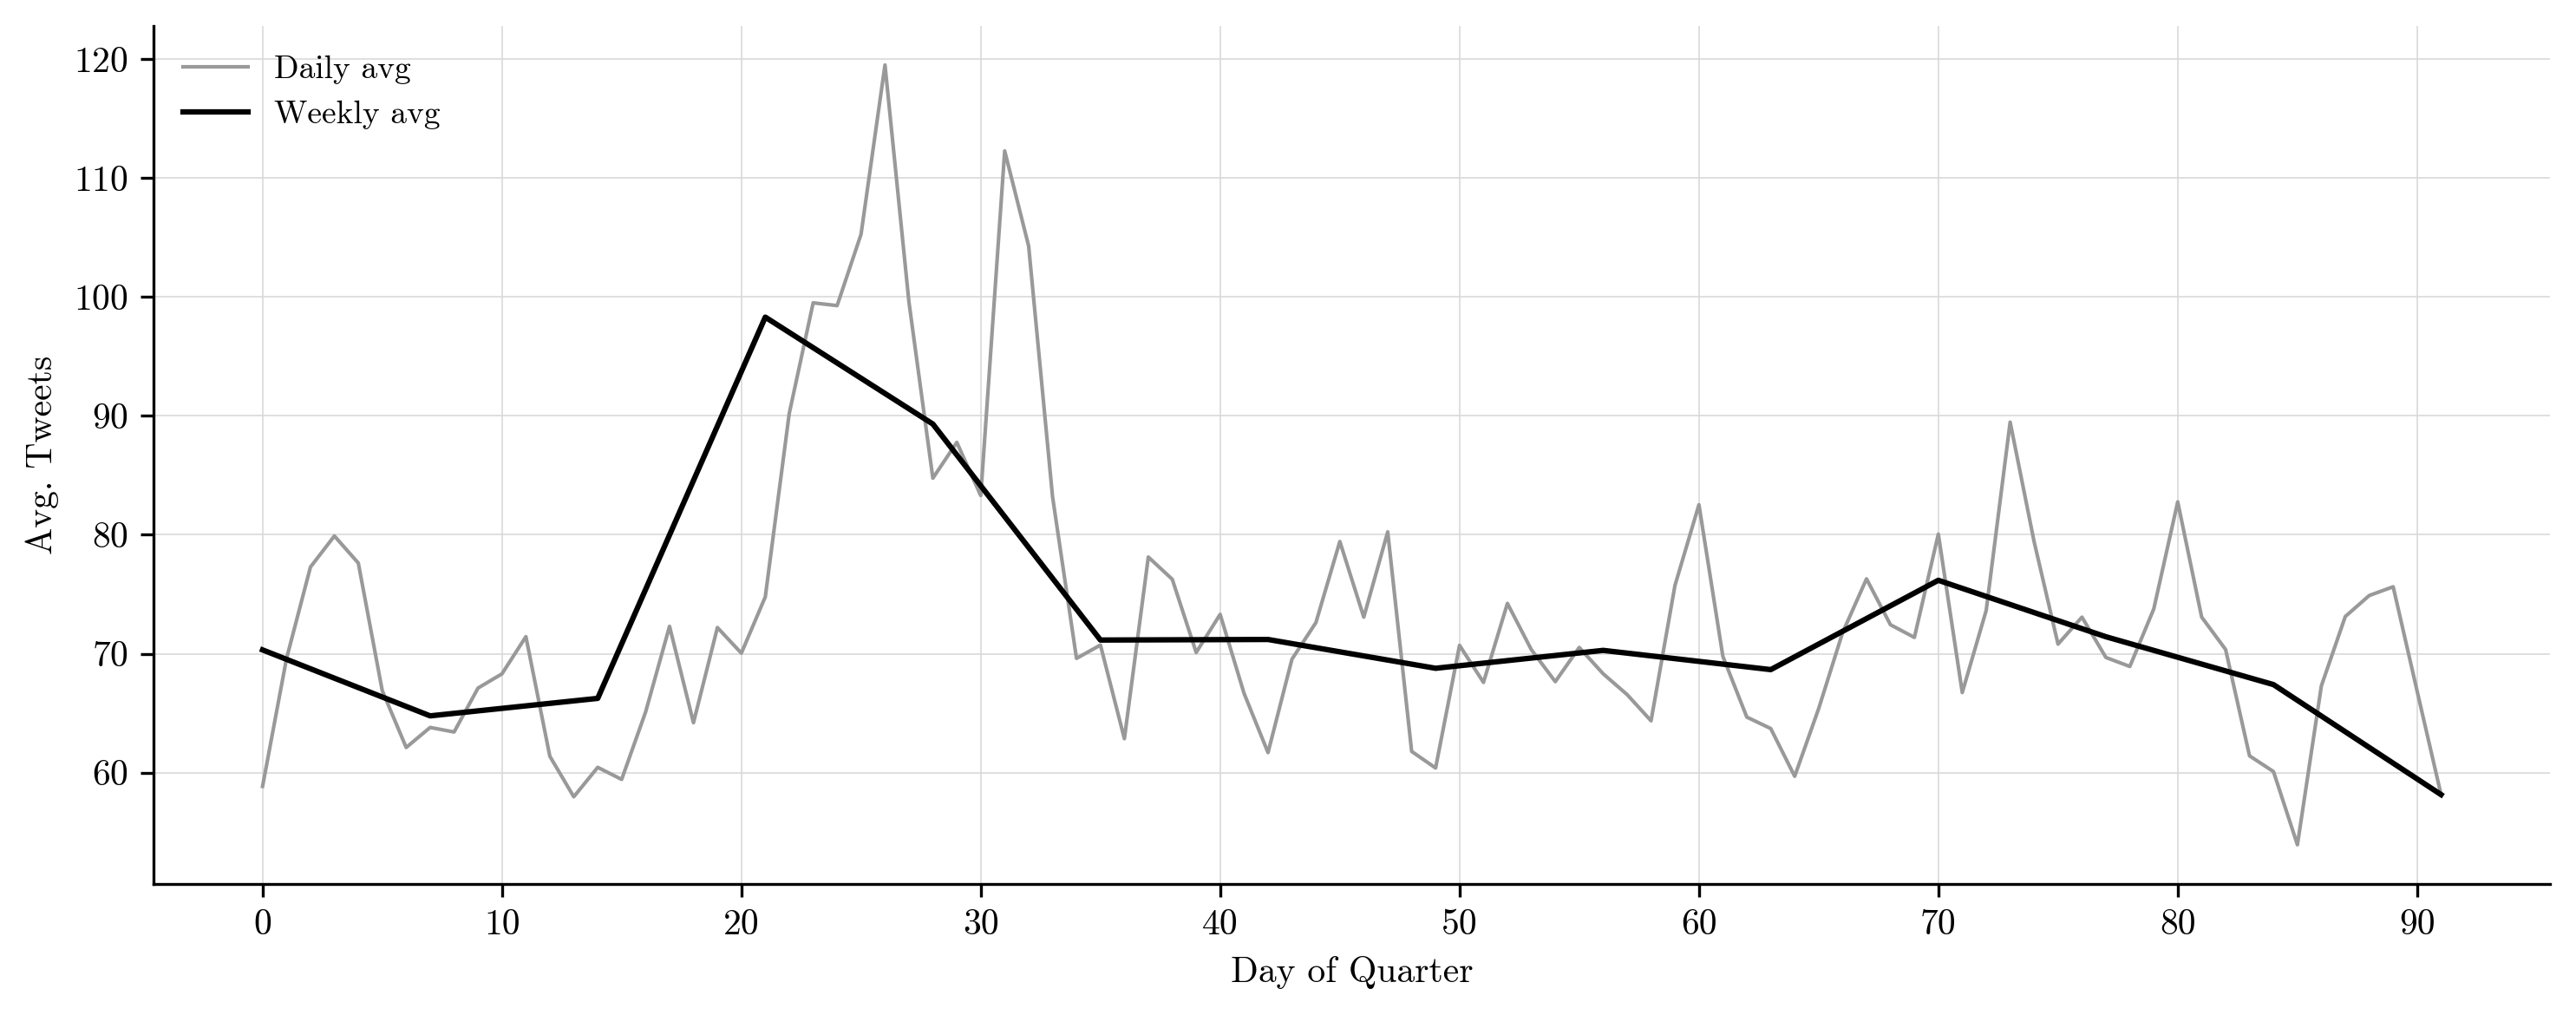

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daily
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
minute = dates.dt.hour * 60 + dates.dt.minute
plot_df = pd.DataFrame({'minute': minute, 'ticker': df['ticker'].fillna('')})
avg_per_minute = plot_df.groupby('minute').size() / len(dates.dt.date.unique())
avg_per_10min = avg_per_minute.groupby(avg_per_minute.index // 10).mean()
x_10min = np.arange(0, 1440, 10)
avg_per_hour = avg_per_minute.groupby(avg_per_minute.index // 60).mean()
x_hour = np.arange(0, 1440, 60)

ax.plot(x_10min / 60, avg_per_10min.values, label="10-min avg", color="0.6", linewidth=1)
ax.plot(x_hour / 60, avg_per_hour.values, label="Hourly avg", color="0.0", linewidth=1.5)
ax.axvline(x=570/60, color='0.4', linestyle='--', linewidth=0.8, label='Market Open')
ax.axvline(x=960/60, color='0.4', linestyle='--', linewidth=0.8, label='Market Close')
ax.set_xlabel("Time of Day")
ax.set_xticks(np.arange(0, 25, 4))
ax.set_ylabel("Avg. Tweets")
ax.legend(loc='upper left', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("media/tweets_daily.png", bbox_inches="tight")
plt.show()

# Weekly
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
hour_of_week = dates.dt.dayofweek * 24 + dates.dt.hour
plot_df_weekly = pd.DataFrame({'hour_week': hour_of_week})
num_weeks = dates.dt.to_period('W').nunique()
avg_per_hour_weekly = plot_df_weekly.groupby('hour_week').size() / num_weeks
avg_per_4h_weekly = avg_per_hour_weekly.groupby(avg_per_hour_weekly.index // 4).mean()
x_4h = np.arange(0, 168, 4)

ax.plot(avg_per_hour_weekly.index, avg_per_hour_weekly.values, label="Hourly avg", color="0.6", linewidth=1)
ax.plot(x_4h, avg_per_4h_weekly.values, label="4-Hour avg", color="0.0", linewidth=1.5)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax.set_xticks(np.arange(12, 168, 24))
ax.set_xticklabels(days)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg. Tweets")
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("media/tweets_weekly.png", bbox_inches="tight")
plt.show()

# Quarterly
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
quarter_start = dates.dt.to_period('Q').dt.to_timestamp()
day_of_quarter = (dates - quarter_start).dt.days
hour_of_quarter = day_of_quarter * 24 + dates.dt.hour
year_quarter = dates.dt.to_period('Q')
df_quarterly = pd.DataFrame({'hour_quarter': hour_of_quarter, 'year_quarter': year_quarter})
counts_per_q_hour = df_quarterly.groupby('hour_quarter').size()
denoms_per_q_hour = df_quarterly.groupby('hour_quarter')['year_quarter'].nunique()
avg_per_hour_quarterly = counts_per_q_hour / denoms_per_q_hour
avg_per_day_q = avg_per_hour_quarterly.groupby(avg_per_hour_quarterly.index // 24).mean()
x_day_q = np.arange(0, len(avg_per_hour_quarterly), 24)
avg_per_week_q = avg_per_hour_quarterly.groupby(avg_per_hour_quarterly.index // (24 * 7)).mean()
x_week_q = np.arange(0, len(avg_per_hour_quarterly), 24 * 7)

ax.plot(x_day_q, avg_per_day_q.values, label="Daily avg", color="0.6", linewidth=1)
ax.plot(x_week_q, avg_per_week_q.values, label="Weekly avg", color="0.0", linewidth=1.5)
ax.set_xlabel("Day of Quarter")
ax.set_ylabel("Avg. Tweets")
ax.set_xticks(np.arange(0, 92*24, 24*10))
ax.set_xticklabels(np.arange(0, 92, 10))
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("media/tweets_quarterly.png", bbox_inches="tight")
plt.show()

## **I.B. Financial Features**

For each ticker, we obtain historical prices from the instruction files and use, daily: 
- price (closing price)
- adjusted returns
- adjusted returns over the previous three days
- adjusted returns over the previous seven days
- standard deviation of adjusted closing prices, over the past 20-days rolling window

We also assign global financial metrics obtained using [FRED](https://fred.stlouisfed.org/categories/46):
- S&P daily volume
- S&P daily returns
- VIX daily

For target, we use
- t1: returns from t+1 market open to t+1 market close
- t7: returns from t+1 market open to t+7 market close

In [ ]:
import pandas as pd
import numpy as np 

dfSPX = pd.read_csv(f'data/Stock_price/^SPX.csv', sep=';')
dfSPX['date'] = pd.to_datetime(dfSPX['Date'])
dfSPX = dfSPX.set_index('date').sort_index()

dfSPX['dlyretSPX'] = dfSPX['Close'].pct_change()
dfSPX['volumeSPX'] = dfSPX['Volume']
dfSPX = dfSPX.loc['2015-01-01':'2019-12-31', ['dlyretSPX', 'volumeSPX']]

dfVIX = pd.read_csv(f'data/Stock_price/^VIX.csv', sep=';')
dfVIX['date'] = pd.to_datetime(dfVIX['observation_date'])
dfVIX = dfVIX.set_index('date').sort_index()
dfVIX = dfVIX.loc['2015-01-01':'2019-12-31', ['VIXCLS']].rename(columns={'VIXCLS': 'VIX'})

dfGlobal = dfSPX.join(dfVIX, how='inner')

In [ ]:
tickers = ("AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA")
df = {}

for ticker in tickers:
    
    # Loading data per ticker
    df_temp = pd.read_csv(f'data/Stock_price/{ticker}.csv')
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp = df_temp.set_index('date').sort_index()
    
    # Filtering time window: 2015-01-01 to 2019-12-31 (margin for returns and SD)
    df_temp = df_temp.loc['2014-12-01':'2020-01-31']

    df_temp['price'] = df_temp['close']
    df_temp['dlyret'] = df_temp['adj close'].pct_change() # Daily adjusted returns
    df_temp['logVolume'] = np.log(df_temp['volume'].clip(lower=1)) 

    df_temp['past_3ret'] = df_temp['dlyret'].rolling(3).mean() # Previous 3 days mean adjusted returns
    df_temp['past_7ret'] = df_temp['dlyret'].rolling(7).mean() # Previous 7 days mean adjusted returns
    df_temp['sdAdjClose'] = df_temp['adj close'].rolling(20).std() # SD of adjusted closing prices, one trading month

    df_temp['ret1'] = (df_temp['close'].shift(-1) - df_temp['open'].shift(-1)) / df_temp['open'].shift(-1) 
    df_temp['ret7'] = (df_temp['close'].shift(-7) - df_temp['open'].shift(-1)) / df_temp['open'].shift(-1)

    # We compute metrics only for the period of interest
    df_temp = df_temp.loc['2015-01-01':'2019-12-31', ['price', 'volume', 'dlyret', 'sdAdjClose', 'past_3ret', 'past_7ret', 'ret1', 'ret7']]

    # Merging with global features
    df_temp = df_temp.join(dfGlobal, how='left')
    df[ticker] = df_temp

    # Create individual df: dfAAPL exists. Without this line: df['AAPL'] instead
    globals()[f'df{ticker}'] = df[ticker]    